<a href="https://colab.research.google.com/github/grsart/BiomolComp/blob/main/Pratica1/P1_Pratica_Sequenciamento_Sanger_Illumina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prática — Análise de Qualidade de Sequenciamento
Nesta prática vamos analisar o resultado de sequenciamento, e tentar entender o *quão confiável é cada base que o
sequenciador me entregou?* em duas tecnologias com filosofias opostas:

| | **Sanger** | **Illumina** |
|---|---|---|
| Reads por corrida | 1 (por capilar) | 10⁶ – 10⁹ |
| Comprimento | 600 – 1000 bp | 50 – 300 bp |
| Cobertura de cada base | 1× (ou 2× com F+R) | 30× – 1000× |
| Estatística útil | perfil de **uma** leitura | distribuição sobre **milhões** |
| Erro dominante | queda no 3′, picos sobrepostos | *phasing*, adaptadores, poli-G |

O fio condutor é o **escore de Phred**:

\begin{equation}
Q = -10\,\log_{10}(P_e) \qquad\Longleftrightarrow\qquad P_e = 10^{-Q/10}
\end{equation}

| Q | Prob. de erro | Acurácia |
|---|---|---|
| 10 | 1 em 10 | 90 % |
| 20 | 1 em 100 | 99 % |
| 30 | 1 em 1 000 | 99,9 % |
| 40 | 1 em 10 000 | 99,99 % |

E a grandeza que vamos usar o tempo todo para dar sentido físico a esse número:

\begin{equation}
E[\text{n° de bases erradas}] = \sum_{i} 10^{-Q_i/10}
\end{equation}

---

### Roteiro

- **Parte 1 — Sanger.** Cromatograma direto do `.ab1`, decodificação ASCII→Phred,
  trimming e consenso *forward*/*reverse*.
- **Parte 2 — Illumina.** Dados **sintéticos**
  e dados **reais do ENA**. Perfil por posição, viés de priming, adaptadores,
  duplicação, poli-G e binning de qualidade.
- **Parte 3 — Contraste** entre as três fontes.
- **Parte 4 — Questões.**

## 0. Preparação do ambiente

Rode esta célula uma única vez.

In [1]:
!pip install -q biopython

import gzip, io, os, sys, textwrap
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import requests
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(linewidth=120)

print("Ambiente pronto.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.2 MB/s eta 0:00:00
Ambiente pronto.


---
# PARTE 1 — Sanger

Duas leituras da **mesma molécula**, uma com o primer *forward* e outra com o *reverse*.
Guarde essa informação: ela é o que torna o consenso da Seção 1.7 possível.

### 1.1 Obtenção dos arquivos

Vamos baixar os arquivos diretamente da pasta no GitHub, por meio do API.

In [2]:
REPO, RAMO, PASTA = "grsart/BiomolComp", "main", "Pratica1"
EXTS = (".fastq", ".fq", ".abd", ".ab1", ".fasta", ".seq")

def via_api():
    r = requests.get(f"https://api.github.com/repos/{REPO}/contents/{PASTA}", timeout=30)
    r.raise_for_status()
    d = r.json()
    if isinstance(d, dict):
        raise RuntimeError(d.get("message", "resposta inesperada"))
    return {it["name"]: it["download_url"] for it in d if it["type"] == "file"}

def via_tarball():
    """Plano B: a API do GitHub limita requisicoes por IP; o tarball nao."""
    import tarfile
    r = requests.get(f"https://codeload.github.com/{REPO}/tar.gz/refs/heads/{RAMO}",
                     timeout=180)
    r.raise_for_status()
    obtidos = {}
    with tarfile.open(fileobj=io.BytesIO(r.content), mode="r:gz") as tf:
        for m in tf.getmembers():
            partes = m.name.split("/")
            if len(partes) >= 3 and partes[1] == PASTA and m.isfile():
                nome = partes[-1]
                if nome.lower().endswith(EXTS):
                    with open(nome, "wb") as fh:
                        fh.write(tf.extractfile(m).read())
                    obtidos[nome] = "tarball"
    return obtidos

arquivos = {}
for tentativa in (via_api, via_tarball):
    try:
        arquivos = tentativa()
        print(f"[{tentativa.__name__}] {len(arquivos)} arquivo(s) localizado(s)")
        break
    except Exception as e:
        print(f"[{tentativa.__name__}] falhou: {type(e).__name__}: {e}")

for nome, url in arquivos.items():
    if url != "tarball" and not os.path.exists(nome) and nome.lower().endswith(EXTS):
        r = requests.get(url, timeout=60); r.raise_for_status()
        open(nome, "wb").write(r.content)

crom = sorted(n for n in os.listdir(".") if n.lower().endswith((".abd", ".ab1")))
fq_s = sorted(n for n in os.listdir(".") if n.lower().endswith((".fastq", ".fq")))
print("\ncromatogramas:", crom)
print("fastq        :", fq_s)

[via_api] 5 arquivo(s) localizado(s)

cromatogramas: ['121107G02F.abd', '121107G02R.abd']
fastq        : ['121107G02F.fastq', '121107G02R.fastq']


Se a listagem automática falhar (rede da universidade, repositório privado), suba os
arquivos manualmente pelo painel lateral do Colab e siga adiante — as células seguintes
apenas procuram por `.ab1` e `.fastq` no diretório de trabalho.

### 1.2 Anatomia do arquivo FASTQ

A formatação do arquivo é importante e essencial para uma leitura correta.

Como vimos em sala de aula, o formato FASTQ descreve cada registro em **4 linhas**:

```
@identificador
ACGTNNACGT...          <- sequencia
+
IIIH>5:;...            <- qualidade, 1 caractere ASCII por base
```

Vamos verificar se isso é verdade **neste arquivo**.

Caso o formato não esteja correto, podemos obter um resultado silenciosamente errado.

In [31]:
def escolher(lista, padrao, rotulo):
    cand = [x for x in lista if padrao.lower() in x.lower()]
    if not cand:
        print(f"[aviso] nenhum arquivo {rotulo} encontrado (padrao '{padrao}')")
        return None
    return cand[0]

FQ_F = escolher(fq_s, "F.", "forward") or (fq_s[0] if fq_s else None)
FQ_R = escolher(fq_s, "R.", "reverse") or (fq_s[1] if len(fq_s) > 1 else None)
print("Forward:", FQ_F, "| Reverse:", FQ_R)

bruto = open(FQ_F, "rb").read()
linhas = bruto.decode().splitlines()

print(f"Total de linhas no arquivo : {len(linhas)}")
print(f"Terminador de linha        : "
      f"{'CRLF (\\r\\n) — arquivo de origem Windows' if b'\r\n' in bruto else 'LF (\\n)'}")
print(f"Linhas iniciadas por '@'   : {sum(l.startswith('@') for l in linhas)}")
print(f"Linhas iguais a '+'        : {sum(l.strip() == '+' for l in linhas)}")

print("\nPrimeiras 30 linhas (60 primeiros caracteres):")
for i, l in enumerate(linhas[:30]):
    print(f"  {i:>2}: {l[:60]}")

sep = next(i for i, l in enumerate(linhas) if l.strip() == "+")
print(f"\nO separador '+' esta na linha {sep}, nao na linha 2.")
print(f"=> Este registro NAO tem 4 linhas: a sequencia esta quebrada em "
      f"{sep-1} linhas de ate 80 caracteres.")
print("   Isso e o 'FASTQ multilinha', um formato legado que ainda circula.")

seq_bruta = "".join(linhas[1:sep])
qual_bruta = "".join(linhas[sep+1:])
print(f"\nApos concatenar -> sequencia: {len(seq_bruta)} car. | "
      f"qualidade: {len(qual_bruta)} car.")
assert len(seq_bruta) == len(qual_bruta), "sequencia e qualidade divergem!"
print("Integridade OK: len(sequencia) == len(qualidade)")

_r = SeqIO.read(FQ_F, "fastq")
print(f"\nO parser do Biopython concorda? {str(_r.seq) == seq_bruta}")

Forward: 121107G02F.fastq | Reverse: 121107G02R.fastq
Total de linhas no arquivo : 26
Terminador de linha        : CRLF (\r\n) — arquivo de origem Windows
Linhas iniciadas por '@'   : 2
Linhas iguais a '+'        : 1

Primeiras 6 linhas (60 primeiros caracteres):
   0: @121107G02F  (942 bases)
   1: CCCCCCCGAACGACGGCAGCGAACTGCTCCTCGACCACCTACTAGGGCGAACTTGGCGCC
   2: CGCCGCCCACTGGCGCGCCGCGCGCGCACCTTCCGCNCCTTTAACTGGCCTACCAGCGCC
   3: CTACTCACACGCTGTTTACTACTTACCACCTGCTTCCNACTCCTTACTNTCCTGCGCTCT
   4: ACACACGCTAGAATAGCGCAACGTTGCAGCGACCTATAGCAGCAGGCAAACAACAGCAAT
   5: TAACTTTCCCTAAACCCCAGAGAAGAGGAGGGAAAACACACTTTCCACACTCCGGAAAAC
   6: GGTTATATTAAATTATGGAAACAATCGGAAAAGGAAAAATTAATTAGGTAACCAATTGGG
   7: NTTCNACTTTACACAACACCTTGGTTACATTATTTACANTCGNTAGGAAAANATATNAAA
   8: AGCAGGAATATCAACCCTTATGCTAAGTTAAACCAATTAAATTCCCCAAACTTATAAAAT
   9: ANATTTGGGGGTTACATATAAGCATTTAACACCCTTTAAACCTTTGGTTACACCTAAACA
  10: AATTAGAAAGAACGGGGGCAATACCCTNACCATATTGANCCAAATTAAATTAGAAAAAGA
  11: TNGGGCGACGTTATGGCAACACCCCACTT

> **Q1.** Se você tivesse cegamente lido a linha 4 para pegar a qualidade, o que teria decodificado?


### 1.3 De ASCII para Phred — na mão

O caractere da linha 4 guarda $Q$ **deslocado de 33** (codificação *Sanger / Phred+33*,
hoje universal):

$$Q = \mathrm{ord}(\text{caractere}) - 33$$

**Q2**: Por qual razão necessito subtrair o valor 33 do index do caractere?

Decodifique as **5 primeiras bases** manualmente antes de rodar a célula.

In [4]:
seq0, qstr0 = seq_bruta, qual_bruta       # ja concatenados na celula anterior

print(f"{'pos':>4} {'base':>4} {'char':>5} {'ASCII':>6} {'Q':>4} {'P(erro)':>10} {'acuracia':>9}")
print("-" * 50)
for i in range(5):
    c = qstr0[i]
    q = ord(c) - 33
    pe = 10 ** (-q / 10)
    print(f"{i+1:>4} {seq0[i]:>4} {repr(c):>5} {ord(c):>6} {q:>4} {pe:>10.2e} {100*(1-pe):>8.3f}%")

print("\nTabela de referencia ASCII -> Phred (Phred+33):")
for ini in range(33, 90, 19):
    print("  " + "  ".join(f"{chr(c)}={c-33:<2}" for c in range(ini, min(ini + 19, 90))))

 pos base  char  ASCII    Q    P(erro)  acuracia
--------------------------------------------------
   1    C   'L'     76   43   5.01e-05   99.995%
   2    C   'I'     73   40   1.00e-04   99.990%
   3    C   'L'     76   43   5.01e-05   99.995%
   4    C   'I'     73   40   1.00e-04   99.990%
   5    C   'B'     66   33   5.01e-04   99.950%

Tabela de referencia ASCII -> Phred (Phred+33):
  !=0   "=1   #=2   $=3   %=4   &=5   '=6   (=7   )=8   *=9   +=10  ,=11  -=12  .=13  /=14  0=15  1=16  2=17  3=18
  4=19  5=20  6=21  7=22  8=23  9=24  :=25  ;=26  <=27  ==28  >=29  ?=30  @=31  A=32  B=33  C=34  D=35  E=36  F=37
  G=38  H=39  I=40  J=41  K=42  L=43  M=44  N=45  O=46  P=47  Q=48  R=49  S=50  T=51  U=52  V=53  W=54  X=55  Y=56


### 1.4 Leitura e visualização do cromatograma

O Biopython lê o formato ABIF nativamente,
inclusive os **quatro canais de fluorescência** brutos. A ordem dos canais está no
campo `FWO_1` do próprio arquivo. Sempre é importante fazer a leitura no arquivo e nunca assumir como fixa.

In [5]:
# Estes arquivos sao ABIF validos (assinatura "ABIF"), mas contem um tag malformado
# que faz o parser estrito do Biopython levantar AssertionError. Tornamos a leitura
# de tags tolerante: um tag ilegivel vira None em vez de abortar o arquivo inteiro.
from Bio.SeqIO import AbiIO
_orig = AbiIO._parse_tag_data
def _tolerante(elem_code, elem_num, raw_data):
    try:
        return _orig(elem_code, elem_num, raw_data)
    except Exception:
        return None
AbiIO._parse_tag_data = _tolerante

CROM_F = escolher(crom, "F.", "cromatograma forward") or (crom[0] if crom else None)

def ler_cromatograma(caminho):
    rec = SeqIO.read(caminho, "abi")
    bruto = rec.annotations["abif_raw"]
    ordem = bruto["FWO_1"].decode()          # NAO assuma "GATC": aqui e "CAGT"
    canais = {b: np.array(bruto[f"DATA{9+i}"]) for i, b in enumerate(ordem)}
    picos = np.array(bruto["PLOC2"])         # indice do trace correspondente a cada base
    return rec, canais, picos, ordem

if CROM_F:
    rec_crom, canais, picos, ordem = ler_cromatograma(CROM_F)
    print("Arquivo        :", CROM_F)
    print("Ordem de canais:", ordem, " (lida do tag FWO_1)")
    print("Bases chamadas :", len(rec_crom.seq))
    print("Pontos do trace:", len(next(iter(canais.values()))))
    print("Tem PCON (qualidade embutida)?",
          "PCON1" in rec_crom.annotations["abif_raw"])
    print("-> a qualidade vira do .fastq; o cromatograma fornece os TRACES.")
else:
    rec_crom = None
    print("Sem cromatograma disponivel — pule para a secao 1.5.")

Arquivo        : 121107G02F.abd
Ordem de canais: CAGT  (lida do tag FWO_1)
Bases chamadas : 942
Pontos do trace: 6636
Tem PCON (qualidade embutida)? False
-> a qualidade vira do .fastq; o cromatograma fornece os TRACES.


Cromatograma e FASTQ conferem: 942 bases.



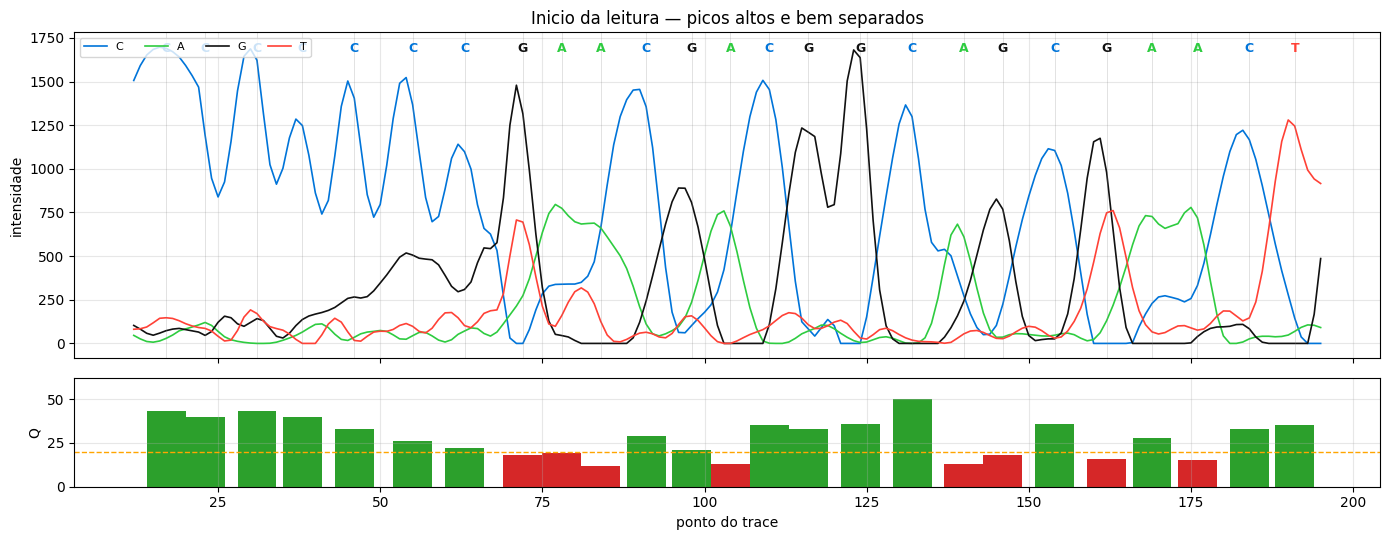

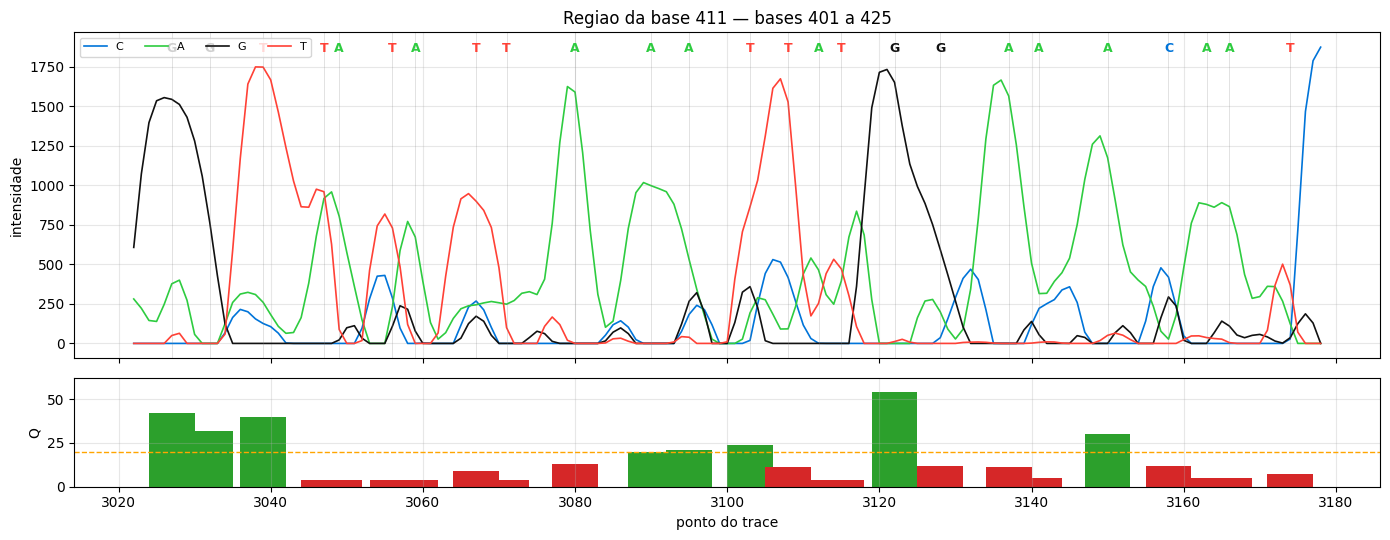

Q da base 411 = 20  (P(erro) = 0.010)


In [6]:
def plot_cromatograma(canais, picos, seq, quals, base_ini, n=25, titulo=""):
    cores = {"A": "#2ecc40", "C": "#0074d9", "G": "#111111", "T": "#ff4136"}
    base_fim = min(base_ini + n, len(picos))
    i0, i1 = picos[base_ini] - 5, picos[base_fim - 1] + 5

    fig, (ax, axq) = plt.subplots(2, 1, figsize=(14, 5.5), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1]})
    x = np.arange(i0, i1)
    for b, tr in canais.items():
        ax.plot(x, tr[i0:i1], color=cores.get(b, "gray"), lw=1.2, label=b)

    for j in range(base_ini, base_fim):
        ax.axvline(picos[j], color="gray", lw=0.4, alpha=0.4)
        ax.text(picos[j], ax.get_ylim()[1] * 0.97, seq[j], ha="center", va="top",
                fontsize=9, color=cores.get(seq[j], "gray"), fontweight="bold")
        axq.bar(picos[j], quals[j], width=6,
                color="#d62728" if quals[j] < 20 else "#2ca02c")

    ax.set_ylabel("intensidade"); ax.legend(ncol=4, loc="upper left", fontsize=8)
    ax.set_title(titulo or f"Cromatograma — bases {base_ini+1} a {base_fim}")
    axq.axhline(20, color="orange", ls="--", lw=1)
    axq.set_ylabel("Q"); axq.set_xlabel("ponto do trace"); axq.set_ylim(0, 62)
    plt.tight_layout(); plt.show()

if rec_crom:
    _r = SeqIO.read(FQ_F, "fastq")
    q_crom = np.array(_r.letter_annotations["phred_quality"])
    s_crom = str(rec_crom.seq)
    assert str(_r.seq).upper() == s_crom.upper(), "cromatograma e fastq divergem!"
    print(f"Cromatograma e FASTQ conferem: {len(s_crom)} bases.\n")

    plot_cromatograma(canais, picos, s_crom, q_crom, 0, 25,
                      "Inicio da leitura — picos altos e bem separados")
    alvo = min(400, len(picos) - 26)
    plot_cromatograma(canais, picos, s_crom, q_crom, alvo, 25,
                      f"Regiao da base 411 — bases {alvo+1} a {alvo+25}")
    print(f"Q da base 411 = {q_crom[410]}  (P(erro) = {10**(-q_crom[410]/10):.3f})")

> **Q3.** Compare os dois cromatogramas. Descreva o que acontece com a **altura**, a
> **largura** e a **separação** dos picos. O que especificamente na base ~411 justifica
> o valor de Q atribuído a ela?

### 1.5 Perfil de qualidade da leitura inteira

Podemos avaliar o perfil GC ao longo da posição e o **número esperado de erros**.

In [7]:
def carregar_fastq(caminho):
    abrir = gzip.open if str(caminho).endswith(".gz") else open
    with abrir(caminho, "rt") as fh:
        regs = list(SeqIO.parse(fh, "fastq"))
    seqs = [str(r.seq).upper() for r in regs]
    quals = [np.asarray(r.letter_annotations["phred_quality"], dtype=np.int16) for r in regs]
    return seqs, quals

def erros_esperados(q):
    return float(np.sum(10.0 ** (-np.asarray(q, float) / 10.0)))

seqsF, qualsF = carregar_fastq(FQ_F)
sF, qF = seqsF[0], qualsF[0]

print(f"Comprimento            : {len(sF)} bp")
print(f"Q medio / mediano      : {qF.mean():.1f} / {np.median(qF):.0f}")
print(f"Bases com Q>=20        : {(qF>=20).sum()} ({100*(qF>=20).mean():.1f}%)")
print(f"Bases com Q>=30        : {(qF>=30).sum()} ({100*(qF>=30).mean():.1f}%)")
print(f"Bases 'N'              : {sF.count('N')} ({100*sF.count('N')/len(sF):.1f}%)")
print(f"ERROS ESPERADOS        : {erros_esperados(qF):.1f} bases erradas em {len(sF)}")

Comprimento            : 942 bp
Q medio / mediano      : 16.9 / 14
Bases com Q>=20        : 341 (36.2%)
Bases com Q>=30        : 178 (18.9%)
Bases 'N'              : 19 (2.0%)
ERROS ESPERADOS        : 143.1 bases erradas em 942


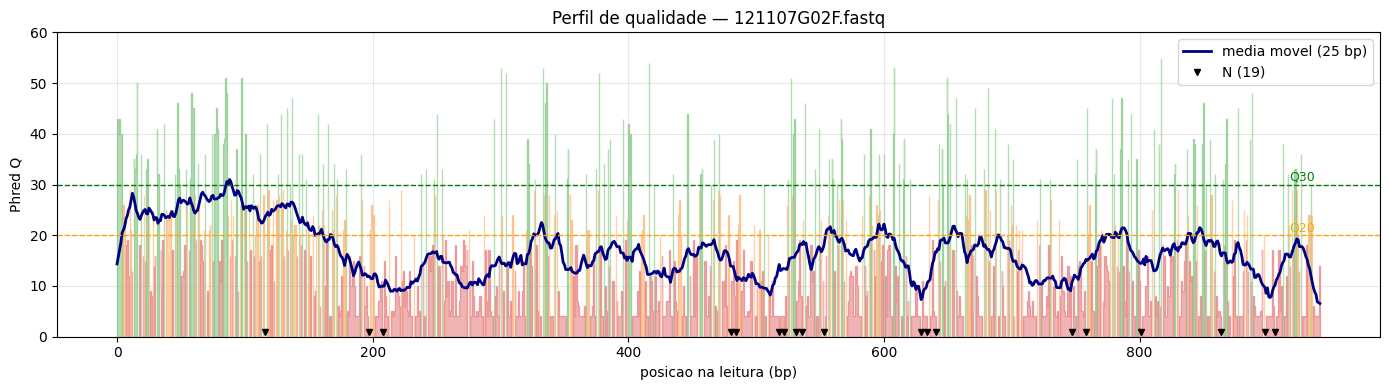

In [8]:
def plot_perfil_sanger(seq, q, titulo, janela=25):
    suave = np.convolve(q, np.ones(janela)/janela, mode="same")
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(np.arange(len(q)), 0, q, where=q >= 30, color="#2ca02c", alpha=.35, step="mid")
    ax.fill_between(np.arange(len(q)), 0, q, where=(q >= 20) & (q < 30), color="#ff7f0e", alpha=.35, step="mid")
    ax.fill_between(np.arange(len(q)), 0, q, where=q < 20, color="#d62728", alpha=.35, step="mid")
    ax.plot(suave, color="navy", lw=2, label=f"media movel ({janela} bp)")
    for y, c in [(20, "orange"), (30, "green")]:
        ax.axhline(y, ls="--", color=c, lw=1)
        ax.text(len(q)*0.995, y+0.7, f"Q{y}", color=c, ha="right", fontsize=9)
    marcaN = [i for i, b in enumerate(seq) if b == "N"]
    if marcaN:
        ax.plot(marcaN, [1]*len(marcaN), "kv", ms=4, label=f"N ({len(marcaN)})")
    ax.set_xlabel("posicao na leitura (bp)"); ax.set_ylabel("Phred Q")
    ax.set_ylim(0, max(q.max()+5, 45)); ax.set_title(titulo); ax.legend(loc="upper right")
    plt.tight_layout(); plt.show()

plot_perfil_sanger(sF, qF, f"Perfil de qualidade — {FQ_F}")

> **Q3.** O erro no Sanger está **concentrado** ou **distribuído**? Divida a leitura em
> terços e calcule o número esperado de erros em cada um. O que isso sugere sobre a
> estratégia de correção?

In [32]:
t = len(qF) // 3
for i, (a, b) in enumerate([(0, t), (t, 2*t), (2*t, len(qF))]):
    trecho = qF[a:b]
    print(f"Terco {i+1} ({a+1:>4}-{b:>4}): Q medio {trecho.mean():5.1f} | "
          f"erros esperados {erros_esperados(trecho):6.1f} "
          f"({100*erros_esperados(trecho)/erros_esperados(qF):4.1f}% do total)")

Terco 1 (   1- 314): Q medio  19.5 | erros esperados   31.7 (22.2% do total)
Terco 2 ( 315- 628): Q medio  15.7 | erros esperados   54.9 (38.3% do total)
Terco 3 ( 629- 942): Q medio  15.6 | erros esperados   56.5 (39.5% do total)


### 1.6 Trimming

Duas estratégias, ambas usadas em produção:

**(a) Janela deslizante.** Mantém o maior trecho contíguo cuja média móvel de $Q$
fica acima de um limiar. É o que o Trimmomatic faz (`SLIDINGWINDOW`).

**(b) Algoritmo de Mott.** É o que os *basecallers* Sanger usam de verdade. Define
$s_i = 10^{-Q_{lim}/10} - 10^{-Q_i/10}$ (positivo quando a base é melhor que o limiar)
e busca o **subarray de soma máxima** — resolvido por **Kadane** em $O(n)$.
Note que é literalmente o problema clássico de algoritmos aplicado a biologia.

In [9]:
def trim_janela(q, janela=20, qmin=20):
    """(a) Maior trecho contiguo com media movel de Q >= qmin."""
    q = np.asarray(q, float)
    if len(q) < janela:
        return 0, len(q)
    media = np.convolve(q, np.ones(janela)/janela, mode="valid")
    idx = np.flatnonzero(media >= qmin)
    if idx.size == 0:
        return 0, 0
    blocos = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
    maior = max(blocos, key=len)
    return int(maior[0]), int(maior[-1] + janela)

def trim_mott(q, qlim=20):
    """(b) Kadane sobre s_i = 10^(-qlim/10) - 10^(-q_i/10)."""
    s = 10.0**(-qlim/10) - 10.0**(-np.asarray(q, float)/10)
    melhor = atual = 0.0
    ini = fim = ini_atual = 0
    for i, v in enumerate(s):
        if atual <= 0:
            atual, ini_atual = v, i
        else:
            atual += v
        if atual > melhor:
            melhor, ini, fim = atual, ini_atual, i + 1
    return ini, fim

def relatorio_trim(seq, q, nome, ini, fim):
    sub = q[ini:fim]
    if len(sub) == 0:
        print(f"{nome:>16}: nada sobrou"); return
    print(f"{nome:>16}: {ini+1:>4}-{fim:<4} | {fim-ini:>4} bp "
          f"({100*(fim-ini)/len(q):4.1f}%) | Q medio {sub.mean():5.1f} | "
          f"erros esp. {erros_esperados(sub):6.2f} | N={seq[ini:fim].count('N')}")

print(f"{'ORIGINAL':>16}: {1:>4}-{len(qF):<4} | {len(qF):>4} bp "
      f"(100.0%) | Q medio {qF.mean():5.1f} | erros esp. {erros_esperados(qF):6.2f} "
      f"| N={sF.count('N')}")
print()
for ql in [5, 8, 10, 12, 15, 20]:
    a, b = trim_mott(qF, ql)
    relatorio_trim(sF, qF, f"Mott qlim={ql}", a, b)
print()
for w, qm in [(20, 15), (20, 20), (50, 15)]:
    a, b = trim_janela(qF, w, qm)
    relatorio_trim(sF, qF, f"janela {w}/Q{qm}", a, b)

        ORIGINAL:    1-942  |  942 bp (100.0%) | Q medio  16.9 | erros esp. 143.10 | N=19

     Mott qlim=5:    1-937  |  937 bp (99.5%) | Q medio  17.0 | erros esp. 141.47 | N=19
     Mott qlim=8:    1-187  |  187 bp (19.9%) | Q medio  24.4 | erros esp.   7.16 | N=1
    Mott qlim=10:    1-166  |  166 bp (17.6%) | Q medio  25.5 | erros esp.   4.27 | N=1
    Mott qlim=12:    1-166  |  166 bp (17.6%) | Q medio  25.5 | erros esp.   4.27 | N=1
    Mott qlim=15:    1-116  |  116 bp (12.3%) | Q medio  26.3 | erros esp.   2.08 | N=0
    Mott qlim=20:  125-141  |   17 bp ( 1.8%) | Q medio  27.8 | erros esp.   0.09 | N=0

   janela 20/Q15:    1-188  |  188 bp (20.0%) | Q medio  24.3 | erros esp.   7.55 | N=1
   janela 20/Q20:    1-167  |  167 bp (17.7%) | Q medio  25.4 | erros esp.   4.67 | N=1
   janela 50/Q15:    1-208  |  208 bp (22.1%) | Q medio  23.2 | erros esp.  11.76 | N=2


Repare no **compromisso**: aumentar o limiar reduz o erro esperado, mas destrói o
comprimento. Não existe "o" valor certo. Para cada situação, um valor ótimo pode ser definido.
Adotamos `qlim=10` por manter um bloco longo e contíguo com erro esperado abaixo de 5
bases.

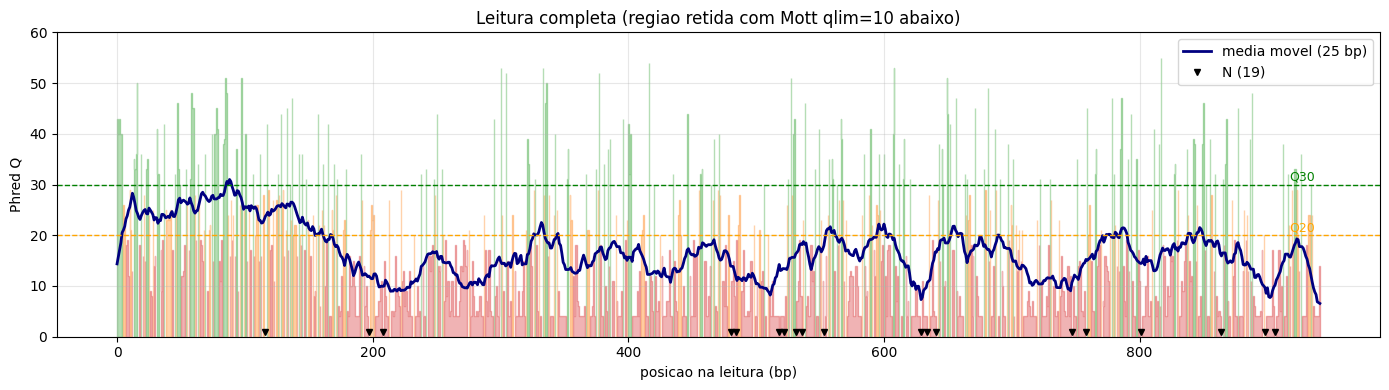

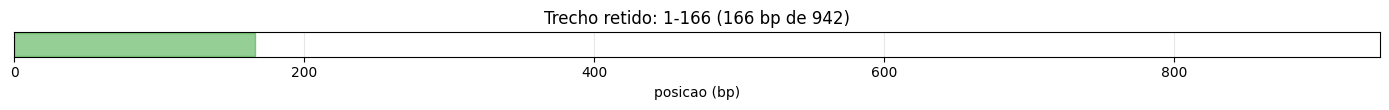

In [10]:
QLIM = 10
im, fm = trim_mott(qF, QLIM)
sF_trim, qF_trim = sF[im:fm], qF[im:fm]

plot_perfil_sanger(sF, qF, f"Leitura completa (regiao retida com Mott qlim={QLIM} abaixo)")
plt.figure(figsize=(14, 1.2))
plt.axhspan(0, 1, xmin=im/len(qF), xmax=fm/len(qF), color="#2ca02c", alpha=.5)
plt.xlim(0, len(qF)); plt.yticks([]); plt.xlabel("posicao (bp)")
plt.title(f"Trecho retido: {im+1}-{fm} ({fm-im} bp de {len(qF)})")
plt.tight_layout(); plt.show()

### 1.7 Reverse complement, sobreposição e consenso

Aqui está a razão de existir das duas leituras. A leitura *reverse* percorre a **fita
complementar na direção oposta**; para compará-la com a *forward* é preciso
(i) complementar as bases e (ii) inverter a ordem — **inclusive do vetor de qualidade**,
que é o erro mais comum nessa etapa.

Mas atenção: **não é garantido que F e R se sobreponham.** Se o inserto for mais longo
que a soma das duas leituras úteis, sobra um buraco no meio. Vamos *testar* isso em vez
de assumir.

In [33]:
if FQ_R:
    seqsR, qualsR = carregar_fastq(FQ_R)
    sR, qR = seqsR[0], qualsR[0]

    sR_rc = str(Seq(sR).reverse_complement())
    qR_rc = qR[::-1]                      # a qualidade tambem inverte!

    irm, frm = trim_mott(qR_rc, QLIM)
    sR_trim, qR_trim = sR_rc[irm:frm], qR_rc[irm:frm]

    print(f"Reverse original      : {len(sR)} bp, Q medio {qR.mean():.1f}")
    print(f"Reverse revcomp+trim  : {len(sR_trim)} bp, Q medio {qR_trim.mean():.1f}")
    print(f"Forward original      : {len(sF)} bp, Q medio {qF.mean():.1f}")
    print(f"Forward trim          : {len(sF_trim)} bp, Q medio {qF_trim.mean():.1f}")
    print("\nPrimeiras 60 bases:")
    print("  F :", sF_trim[:60])
    print("  R':", sR_trim[:60])
else:
    print("Arquivo reverse ausente — secao 1.7 sera pulada.")

Reverse original      : 620 bp, Q medio 19.2
Reverse revcomp+trim  : 250 bp, Q medio 27.6
Forward original      : 942 bp, Q medio 16.9
Forward trim          : 166 bp, Q medio 25.5

Primeiras 60 bases:
  F : CCCCCCCGAACGACGGCAGCGAACTGCTCCTCGACCACCTACTAGGGCGAACTTGGCGCC
  R': TTGTGTACATATCCCAGCTAATGTTTAGTCATGGTCTAATAACTTAGCTGTACTAAATCA


#### O teste de sobreposição — e por que ele precisa de um controle

Um alinhador **local sempre devolve alguma coisa**: duas sequências aleatórias de ~200 bp
compartilham, por acaso, trechos de 10–15 bp. Portanto um score isolado não significa
nada. Precisamos de um **controle positivo**: qual score uma sobreposição *verdadeira*
produziria com estes mesmos dados?

Construímos o controle tomando 120 bp da própria leitura F e introduzindo 3 % de
mutações — imitando uma segunda leitura da mesma região.

In [12]:
from Bio.Align import PairwiseAligner

ALINHADOR = PairwiseAligner(mode="local", match_score=2, mismatch_score=-3,
                            open_gap_score=-7, extend_gap_score=-2)

def testar_sobreposicao(A, B, rot):
    aln = ALINHADOR.align(A, B)[0]
    n = sum(a1 - a0 for a0, a1 in aln.aligned[0])
    mm = sum(1 for (a0, a1), (b0, b1) in zip(*aln.aligned)
             for a, b in zip(range(a0, a1), range(b0, b1)) if A[a] != B[b])
    ident = 100 * (1 - mm / max(n, 1))
    print(f"{rot:<34} score={aln.score:>7.0f} | alinhado {n:>4} bp | ident {ident:5.1f}%")
    return aln, n, ident

if FQ_R:
    rng_c = np.random.default_rng(0)
    trecho = list(sF_trim[:120] if len(sF_trim) >= 120 else sF_trim)
    for i in rng_c.choice(len(trecho), max(1, int(0.03*len(trecho))), replace=False):
        trecho[i] = rng_c.choice([b for b in "ACGT" if b != trecho[i]])
    controle = "".join(trecho)

    print("CONTROLE POSITIVO (sobreposicao real, 3% de divergencia):")
    testar_sobreposicao(sF_trim, controle, "  F vs copia mutada de F")
    print("\nCONTROLE NEGATIVO (nao ha relacao esperada):")
    testar_sobreposicao(sF_trim, "".join(rng_c.choice(list("ACGT"), len(sF_trim))),
                        "  F vs sequencia aleatoria")
    print("\nTESTE REAL:")
    testar_sobreposicao(sF_trim, sR_trim, "  F vs R' (ambos aparados)")
    testar_sobreposicao(sF, sR_rc, "  F vs R' (leituras completas)")

CONTROLE POSITIVO (sobreposicao real, 3% de divergencia):
  F vs copia mutada de F           score=    225 | alinhado  120 bp | ident  97.5%

CONTROLE NEGATIVO (nao ha relacao esperada):
  F vs sequencia aleatoria         score=     14 | alinhado    7 bp | ident 100.0%

TESTE REAL:
  F vs R' (ambos aparados)         score=     18 | alinhado    9 bp | ident 100.0%
  F vs R' (leituras completas)     score=     19 | alinhado   12 bp | ident  91.7%


> **Q4.** Compare os quatro scores. O "alinhamento" entre F e R′ é distinguível do
> alinhamento contra uma sequência **aleatória**? Qual é sua conclusão sobre a
> sobreposição?

#### Consequência: estimando o tamanho do inserto

Sem sobreposição, as duas leituras cobrem **extremidades opostas** de um inserto maior,
com um vão não sequenciado no meio:

```
inserto  |==================================================|
F        |---->                                              (le da esquerda)
R                                              <----|        (le da direita)
                    ^^^^^^^^^^^^^^^^^^^^^
                    vao nao coberto
```

Logo o inserto satisfaz $L_{\text{inserto}} > L_F + L_R$ — um **limite inferior**, não uma medida.

In [13]:
if FQ_R:
    print(f"Leitura F util  : {len(sF_trim):>4} bp")
    print(f"Leitura R util  : {len(sR_trim):>4} bp")
    print(f"-> inserto > {len(sF_trim)+len(sR_trim)} bp (limite inferior)")
    print(f"   usando as leituras brutas: > {len(sF)+len(sR)} bp")
    print("\nPara fechar o vao seria preciso: primer walking, uma leitura mais longa,")
    print("ou sequenciamento por outra tecnologia (Nanopore/PacBio).")

Leitura F util  :  166 bp
Leitura R util  :  250 bp
-> inserto > 416 bp (limite inferior)
   usando as leituras brutas: > 1562 bp

Para fechar o vao seria preciso: primer walking, uma leitura mais longa,
ou sequenciamento por outra tecnologia (Nanopore/PacBio).


#### A regra de consenso — demonstrada em um par que *de fato* se sobrepõe

O código do consenso continua sendo o objeto de aprendizado. Aplicamo-lo a um par
sintético com sobreposição real, construído a partir da própria leitura F: onde as duas
concordam, as evidências **somam**; onde discordam, vence o maior $Q$ e a confiança
**cai** para a diferença entre elas.

In [14]:
def consenso(A, qa, B, qb):
    aln = ALINHADOR.align(A, B)[0]
    cons, qcons, discord = [], [], []
    for (a0, a1), (b0, b1) in zip(*aln.aligned):
        for a, b in zip(range(a0, a1), range(b0, b1)):
            bA, bB, QA, QB = A[a], B[b], int(qa[a]), int(qb[b])
            if bA == bB:
                cons.append(bA); qcons.append(min(60, QA + QB))    # evidencias somam
            else:
                escolha = bA if QA >= QB else bB
                cons.append(escolha); qcons.append(abs(QA - QB))   # evidencias se cancelam
                discord.append((a, bA, QA, bB, QB, escolha))
    return "".join(cons), np.array(qcons), discord, aln

# par sintetico: mesma regiao lida "duas vezes", com erros e perfis de Q independentes
rng_d = np.random.default_rng(7)
regiao = sF_trim[:min(150, len(sF_trim))]
qA = np.clip(rng_d.normal(28, 7, len(regiao)), 2, 50).astype(int)
qB = np.clip(rng_d.normal(28, 7, len(regiao)), 2, 50).astype(int)

def corromper(seq, q):
    s = list(seq)
    erra = rng_d.random(len(s)) < 10.0**(-np.asarray(q, float)/10)   # erro ~ P(Q)!
    for i in np.flatnonzero(erra):
        s[i] = rng_d.choice([b for b in "ACGT" if b != s[i]])
    return "".join(s)

sA, sB = corromper(regiao, qA), corromper(regiao, qB)
cons_seq, cons_q, discord, _ = consenso(sA, qA, sB, qB)

acuracia = lambda s: 100*sum(x == y for x, y in zip(s, regiao))/len(regiao)
print(f"{'':<12}{'Q medio':>9}{'erros esp.':>12}{'acuracia real':>15}")
print("-"*48)
for rot, s, q in [("Leitura A", sA, qA), ("Leitura B", sB, qB), ("CONSENSO", cons_seq, cons_q)]:
    print(f"{rot:<12}{np.mean(q):>9.1f}{erros_esperados(q):>12.2f}{acuracia(s):>14.1f}%")
print(f"\nDiscordancias resolvidas: {len(discord)}")
print(f"{'pos':>5} {'A':>2} {'QA':>4} {'B':>2} {'QB':>4} -> {'escolha':>7} {'correta?':>9}")
for d in discord[:12]:
    print(f"{d[0]:>5} {d[1]:>2} {d[2]:>4} {d[3]:>2} {d[4]:>4} -> {d[5]:>7} "
          f"{'sim' if d[5]==regiao[d[0]] else 'NAO':>9}")

              Q medio  erros esp.  acuracia real
------------------------------------------------
Leitura A        26.4        0.93         100.0%
Leitura B        26.8        1.23          99.3%
CONSENSO         51.8        0.02         100.0%

Discordancias resolvidas: 1
  pos  A   QA  B   QB -> escolha  correta?
  100  C   25  G    5 ->       C       sim


> **Q5.** No par sintético, a regra "vence o maior Q" acertou em que fração das
> discordâncias? Ela é melhor que escolher ao acaso (50 %)?

Regra 'maior Q vence': 1/1 = 100.0% de acerto (acaso = 50%)


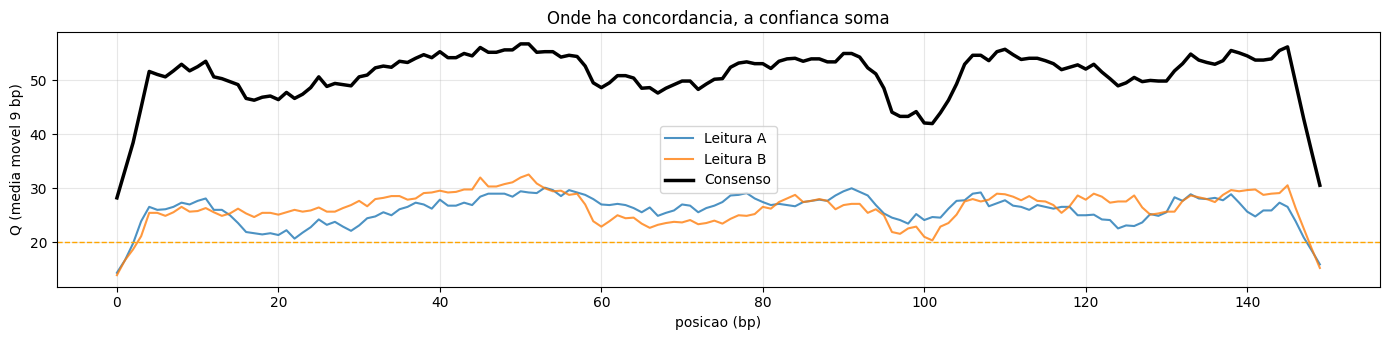

In [15]:
if discord:
    acertos = sum(1 for d in discord if d[5] == regiao[d[0]])
    print(f"Regra 'maior Q vence': {acertos}/{len(discord)} = "
          f"{100*acertos/len(discord):.1f}% de acerto (acaso = 50%)")

    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(np.convolve(qA, np.ones(9)/9, "same"), label="Leitura A", alpha=.8)
    ax.plot(np.convolve(qB, np.ones(9)/9, "same"), label="Leitura B", alpha=.8)
    ax.plot(np.convolve(cons_q, np.ones(9)/9, "same"), label="Consenso", lw=2.5, color="k")
    ax.axhline(20, ls="--", color="orange", lw=1)
    ax.set_xlabel("posicao (bp)"); ax.set_ylabel("Q (media movel 9 bp)")
    ax.set_title("Onde ha concordancia, a confianca soma"); ax.legend()
    plt.tight_layout(); plt.show()

---
# PARTE 2 — Illumina

Agora saímos de uma leitura para dezenas de milhares. Tudo o que era um número vira uma
**distribuição** — e defeitos que eram invisíveis no Sanger passam a saltar aos olhos.

Vamos usar **duas fontes em paralelo**:

1. **Sintética**, com defeitos que conhecemos.
2. **Real**, baixada do ENA.

### 2.1 Gerador sintético com defeitos plantados

Defeitos injetados de propósito:

| Defeito | Como é plantado |
|---|---|
| Queda de Q no 3′ | perfil sigmoide decrescente |
| Instabilidade nos primeiros bp | penalidade nas 8 primeiras posições |
| Viés de priming aleatório | composição desbalanceada nos 12 primeiros bp |
| Adaptador (*read-through*) | 12 % dos reads recebem `AGATCGGAAGAGC` |
| Bases `N` | onde Q colapsa abaixo de 4 |
| Duplicatas de PCR | 3 % dos reads repetidos |
| **Binning de Q** (NovaSeq) | Q colapsado em 4 valores |
| **Cauda poli-G** (NovaSeq) | 5 % dos reads terminam em G |

In [16]:
ADAPTADOR = "AGATCGGAAGAGC"      # inicio do TruSeq Universal Adapter

def gerar_fastq(caminho, n_reads=50_000, L=150, seed=42, gc=0.51,
                frac_adaptador=0.12, frac_dup=0.03, plataforma="hiseq"):
    rng = np.random.default_rng(seed)
    COD = np.array([65, 67, 71, 84], np.uint8)         # A C G T
    p_global = np.array([(1-gc)/2, gc/2, gc/2, (1-gc)/2])

    S = COD[rng.choice(4, size=(n_reads, L), p=p_global)]

    # viés de priming aleatório nos 12 primeiros bp
    p_bias = np.array([0.34, 0.19, 0.17, 0.30])
    S[:, :12] = COD[rng.choice(4, size=(n_reads, 12), p=p_bias)]

    # perfil de qualidade
    pos = np.arange(L)
    perfil = 38 - 27 / (1 + np.exp(-(pos - 0.66*L) / (0.07*L)))
    perfil[:8] -= np.linspace(6, 0, 8)
    Q = perfil + rng.normal(0, 2.5, (n_reads, 1)) + rng.normal(0, 1.5, (n_reads, L))
    Q = np.clip(Q, 2, 41)

    # adaptador em fragmentos curtos
    ad = np.frombuffer(ADAPTADOR.encode(), np.uint8)
    alvo = rng.random(n_reads) < frac_adaptador
    for i in np.flatnonzero(alvo):
        ini = int(rng.integers(L//2, L-5))
        k = min(len(ad), L-ini)
        S[i, ini:ini+k] = ad[:k]
        Q[i, ini:] *= 0.75

    if plataforma == "novaseq":
        Q = np.array([2, 12, 23, 37])[np.digitize(Q, [7, 18, 30])].astype(float)
        polig = rng.random(n_reads) < 0.05
        for i in np.flatnonzero(polig):
            k = int(rng.integers(10, 40))
            S[i, -k:] = 71                              # 'G'
            Q[i, -k:] = 12

    S[Q < 4] = 78                                       # 'N'
    Q = Q.astype(np.uint8)

    idx = np.arange(n_reads)
    if frac_dup > 0:
        dup = rng.choice(n_reads, int(frac_dup*n_reads), replace=False)
        idx = np.concatenate([idx, dup]); rng.shuffle(idx)

    with gzip.open(caminho, "wt") as fh:
        for j, i in enumerate(idx):
            fh.write(f"@SIM:1:FC1:1:{j}:{rng.integers(9999)}:{rng.integers(9999)} 1:N:0:ATCACG\n"
                     f"{S[i].tobytes().decode()}\n+\n"
                     f"{(Q[i]+33).tobytes().decode('latin-1')}\n")
    return caminho, len(idx)

for plat, seed in [("hiseq", 42), ("novaseq", 7)]:
    c, n = gerar_fastq(f"sintetico_{plat}.fastq.gz", plataforma=plat, seed=seed)
    print(f"{c}: {n} reads, {os.path.getsize(c)/1e6:.1f} MB")

sintetico_hiseq.fastq.gz: 51500 reads, 7.5 MB
sintetico_novaseq.fastq.gz: 51500 reads, 3.6 MB


### 2.2 Dados reais do ENA

O ENA serve FASTQ por HTTP e tem uma API que devolve a URL exata. Baixamos apenas os primeiros *N* reads, descompactando em streaming, para não
puxar centenas de MB.

In [17]:
ACESSOS = ["SRR2584863", "SRR2589044", "ERR1053730"]   # tenta em ordem
N_READS_REAIS = 50_000

def consultar_ena(acc):
    url = ("https://www.ebi.ac.uk/ena/portal/api/filereport"
           f"?accession={acc}&result=read_run"
           "&fields=run_accession,instrument_model,library_strategy,"
           "read_count,base_count,fastq_ftp,fastq_bytes&format=tsv")
    r = requests.get(url, timeout=40); r.raise_for_status()
    linhas = [l.split("\t") for l in r.text.strip().split("\n")]
    if len(linhas) < 2:
        raise RuntimeError("acesso sem resultados")
    return dict(zip(linhas[0], linhas[1]))

def baixar_subamostra(url, destino, n_reads=50_000):
    if not url.startswith("http"):
        url = "https://" + url
    alvo = n_reads * 4
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        r.raw.decode_content = False
        fluxo = io.TextIOWrapper(gzip.GzipFile(fileobj=r.raw), encoding="utf-8")
        with gzip.open(destino, "wt") as out:
            for i, linha in enumerate(fluxo):
                if i >= alvo:
                    break
                out.write(linha)
    return destino

FQ_REAL, META_REAL = None, None
for acc in ACESSOS:
    try:
        meta = consultar_ena(acc)
        print(f"{acc}: {meta['instrument_model']} | {meta['library_strategy']} | "
              f"{int(meta['read_count']):,} reads")
        url = meta["fastq_ftp"].split(";")[0]
        FQ_REAL = baixar_subamostra(url, f"real_{acc}.fastq.gz", N_READS_REAIS)
        META_REAL = meta
        print(f"  -> baixado: {FQ_REAL} ({os.path.getsize(FQ_REAL)/1e6:.1f} MB)")
        break
    except Exception as e:
        print(f"{acc}: falhou ({type(e).__name__}: {e})")

if FQ_REAL is None:
    print("\n[aviso] Nenhum download real funcionou. A pratica segue apenas com os "
          "dados sinteticos — todas as celulas seguintes tratam esse caso.")

SRR2584863: falhou (ReadTimeout: HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=40))
SRR2589044: Illumina HiSeq 2500 | WGS | 1,107,090 reads
  -> baixado: real_SRR2589044.fastq.gz (6.1 MB)


### 2.3 Carregamento vetorizado

O ponto crítico de escala: guardar as qualidades como listas Python custa ~28 bytes por
inteiro. Para 50 000 × 150 bases isso passa de 200 MB. Guardamos tudo em **matrizes
NumPy**, com `NaN` no preenchimento de reads mais curtos.

In [18]:
def carregar_matrizes(caminho, max_reads=None):
    """Retorna (S, Q, comprimentos, seqs): S = codigos ASCII uint8, Q = float32 com NaN.

    Leitor rapido que ASSUME 4 linhas por registro — valido para Illumina, mas nao
    para o FASTQ multilinha da Secao 1.2. Por isso a verificacao abaixo.
    """
    abrir = gzip.open if str(caminho).endswith(".gz") else open
    with abrir(caminho, "rt") as fh:
        cab = [next(fh).rstrip() for _ in range(4)]
    if cab[2].strip() != "+" or len(cab[1]) != len(cab[3]):
        raise ValueError(f"{caminho} nao parece FASTQ de 4 linhas — use SeqIO.parse")

    seqs, quals = [], []
    with abrir(caminho, "rt") as fh:
        for i, linha in enumerate(fh):
            r = i % 4
            if r == 1:
                seqs.append(linha.strip())
            elif r == 3:
                quals.append(linha.strip())
            if max_reads and len(seqs) >= max_reads and r == 3:
                break
    n = len(seqs); L = max(map(len, seqs))
    S = np.zeros((n, L), np.uint8)
    Q = np.full((n, L), np.nan, np.float32)
    comp = np.empty(n, np.int32)
    for i, (s, q) in enumerate(zip(seqs, quals)):
        m = len(s); comp[i] = m
        S[i, :m] = np.frombuffer(s.encode(), np.uint8)
        Q[i, :m] = np.frombuffer(q.encode(), np.uint8).astype(np.float32) - 33
    return S, Q, comp, seqs

DADOS = {}
for rot, cam in [("HiSeq sint.",   "sintetico_hiseq.fastq.gz"),
                 ("NovaSeq sint.", "sintetico_novaseq.fastq.gz"),
                 ("Real (ENA)",    FQ_REAL)]:
    if cam and os.path.exists(cam):
        S, Q, comp, seqs = carregar_matrizes(cam, max_reads=50_000)
        DADOS[rot] = dict(S=S, Q=Q, comp=comp, seqs=seqs, arquivo=cam)
        print(f"{rot:<15}: {S.shape[0]:>6,} reads x {S.shape[1]:>3} bp | "
              f"{Q.nbytes/1e6:5.1f} MB em memoria")

HiSeq sint.    : 50,000 reads x 150 bp |  30.0 MB em memoria
NovaSeq sint.  : 50,000 reads x 150 bp |  30.0 MB em memoria
Real (ENA)     : 50,000 reads x 150 bp |  30.0 MB em memoria


### 2.4 Painel de qualidade

**Cada posição tem milhares de observações**, então mediana, quartis e *whiskers* significam algo.

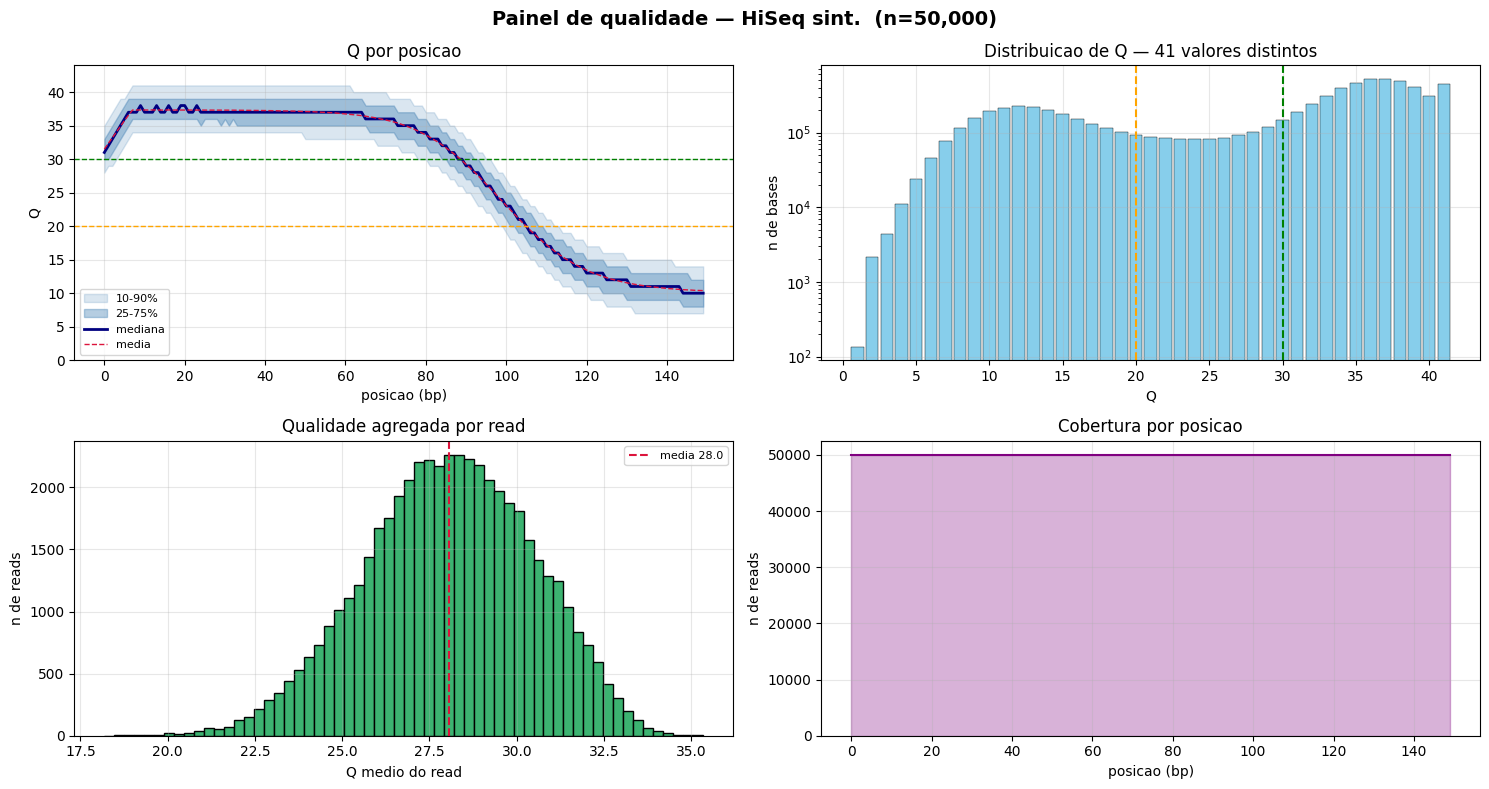

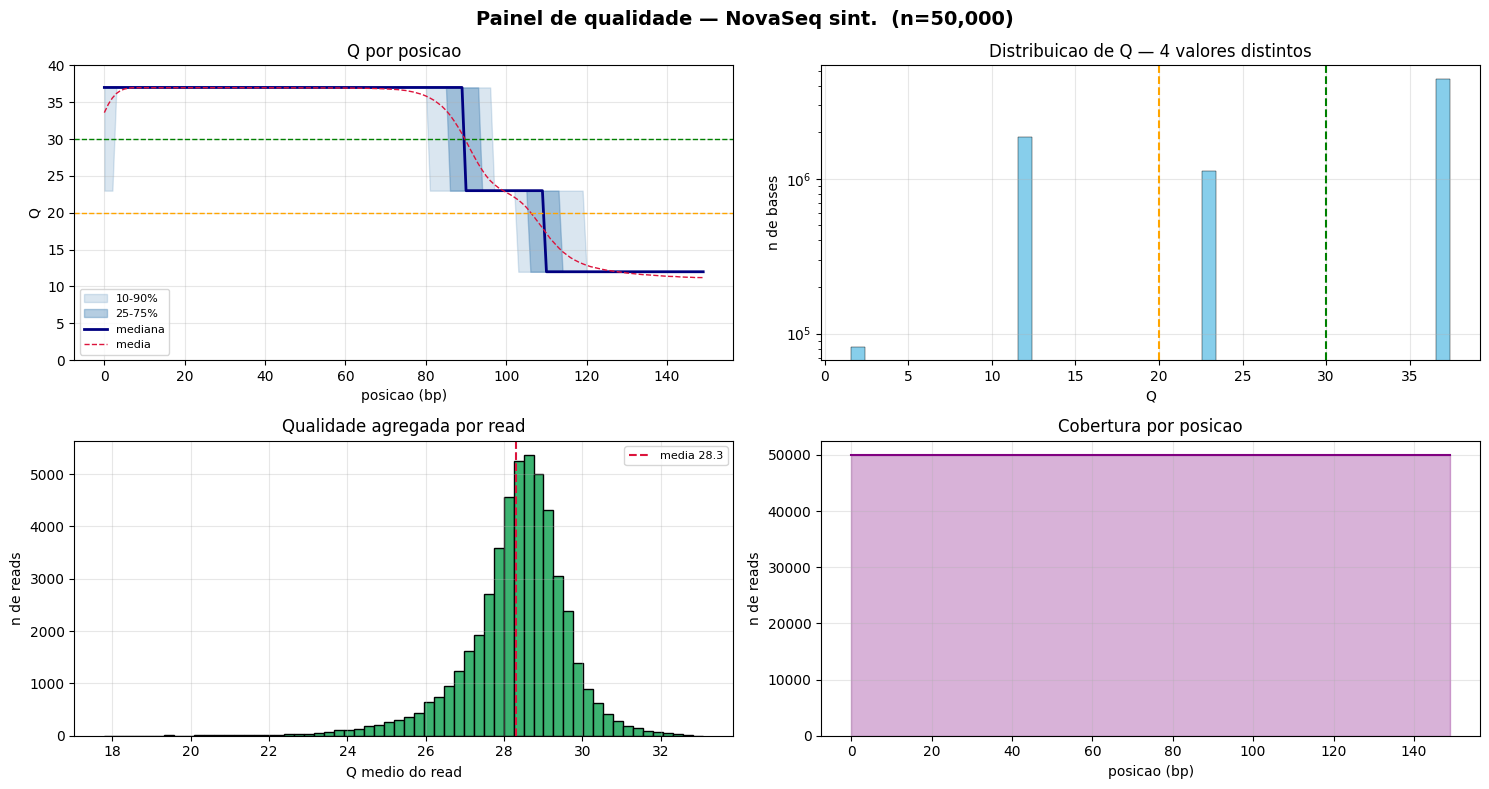

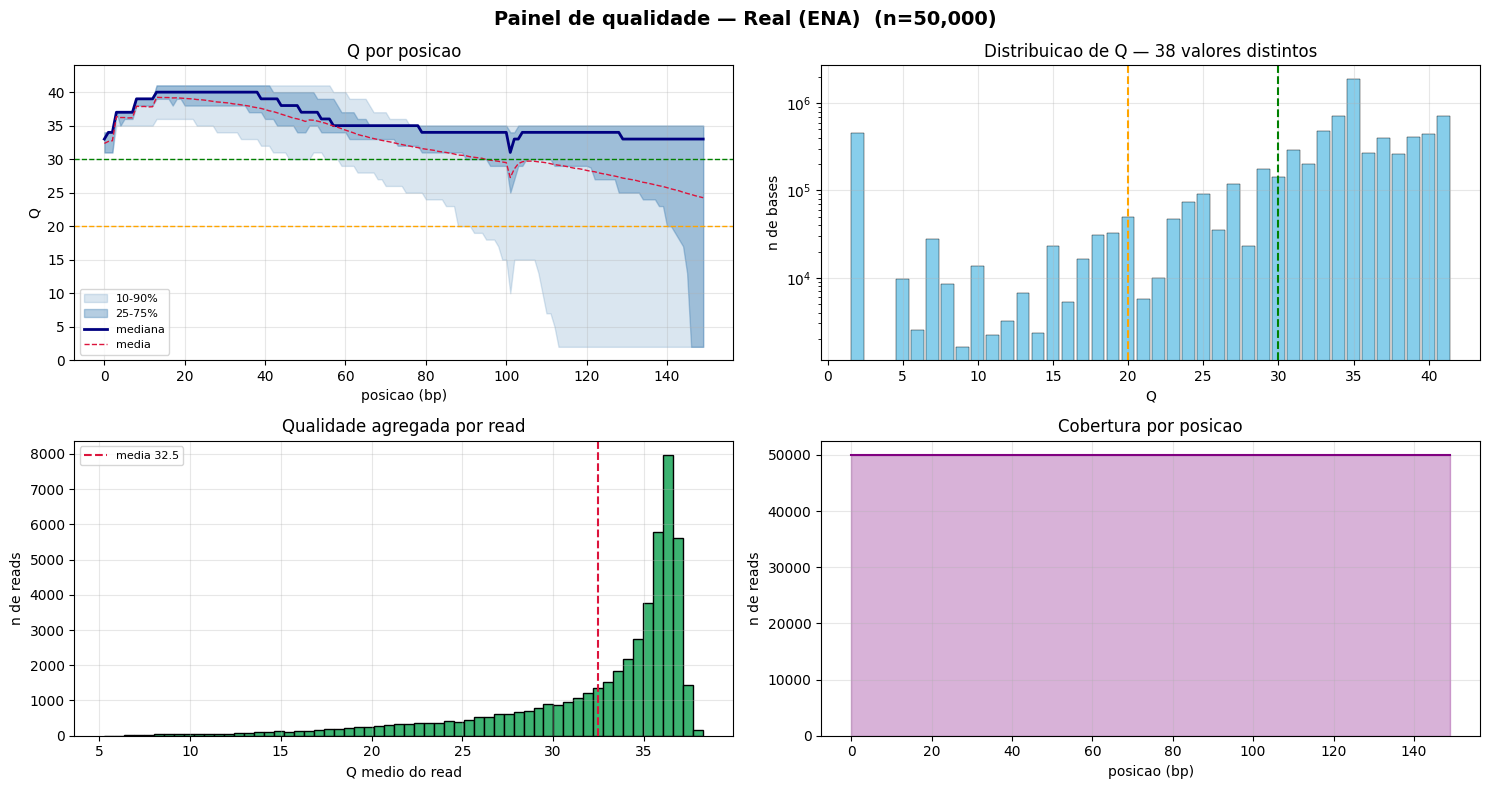

In [19]:
def painel_qualidade(d, rot):
    S, Q, comp = d["S"], d["Q"], d["comp"]
    n, L = Q.shape
    cob = np.sum(~np.isnan(Q), axis=0)
    q10, q25, q50, q75, q90 = np.nanpercentile(Q, [10, 25, 50, 75, 90], axis=0)
    med = np.nanmean(Q, axis=0)
    qmedia_read = np.nanmean(Q, axis=1)
    todos = Q[~np.isnan(Q)]

    fig, axs = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle(f"Painel de qualidade — {rot}  (n={n:,})", fontsize=14, fontweight="bold")

    a = axs[0, 0]
    a.fill_between(range(L), q10, q90, color="steelblue", alpha=.20, label="10-90%")
    a.fill_between(range(L), q25, q75, color="steelblue", alpha=.40, label="25-75%")
    a.plot(q50, color="navy", lw=2, label="mediana")
    a.plot(med, color="crimson", lw=1, ls="--", label="media")
    a.axhline(20, ls="--", color="orange", lw=1); a.axhline(30, ls="--", color="green", lw=1)
    a.set_xlabel("posicao (bp)"); a.set_ylabel("Q"); a.set_ylim(0, np.nanmax(Q)+3)
    a.set_title("Q por posicao"); a.legend(fontsize=8, loc="lower left")

    a = axs[0, 1]
    vals, cnts = np.unique(todos.astype(int), return_counts=True)
    a.bar(vals, cnts, width=0.85, color="skyblue", edgecolor="k", lw=.3)
    a.axvline(20, ls="--", color="orange"); a.axvline(30, ls="--", color="green")
    a.set_xlabel("Q"); a.set_ylabel("n de bases"); a.set_yscale("log")
    a.set_title(f"Distribuicao de Q — {len(vals)} valores distintos")

    a = axs[1, 0]
    a.hist(qmedia_read, bins=60, color="mediumseagreen", edgecolor="k", lw=.3)
    a.axvline(qmedia_read.mean(), color="crimson", ls="--",
              label=f"media {qmedia_read.mean():.1f}")
    a.set_xlabel("Q medio do read"); a.set_ylabel("n de reads")
    a.set_title("Qualidade agregada por read"); a.legend(fontsize=8)

    a = axs[1, 1]
    a.plot(cob, color="purple"); a.fill_between(range(L), cob, alpha=.3, color="purple")
    a.set_xlabel("posicao (bp)"); a.set_ylabel("n de reads")
    a.set_ylim(0, n*1.05); a.set_title("Cobertura por posicao")

    plt.tight_layout(); plt.show()

for rot, d in DADOS.items():
    painel_qualidade(d, rot)

> **Q7.** O gráfico de cobertura por posição é uma linha reta até o fim em dados de
> comprimento fixo. **Em que situação ele deixaria de ser reto** e passaria a carregar
> informação? (Volte a esse gráfico depois da Seção 2.10.). Discuta comparativamente os quatro gráficos entre as amostras.

### 2.5 Composição de bases por posição — o viés de priming

**Q8.** Nos gráficos abaixo, qual região representa viés e qual região apresenta o perfil esperado? Justifique

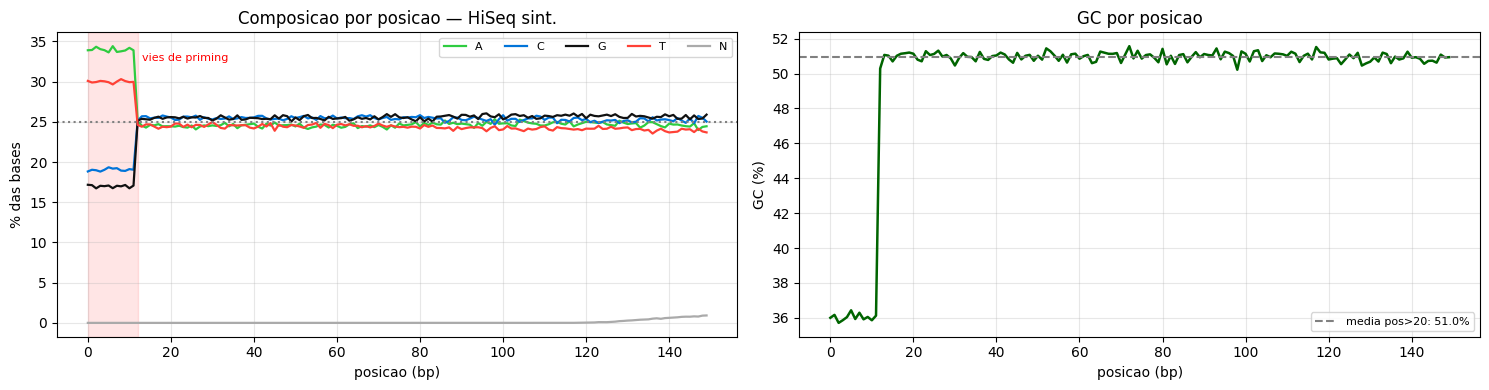

HiSeq sint.: bases N = 0.089% | desvio maximo de 25% -> 12 primeiros bp: 9.0 p.p. | resto do read: 0.7 p.p.


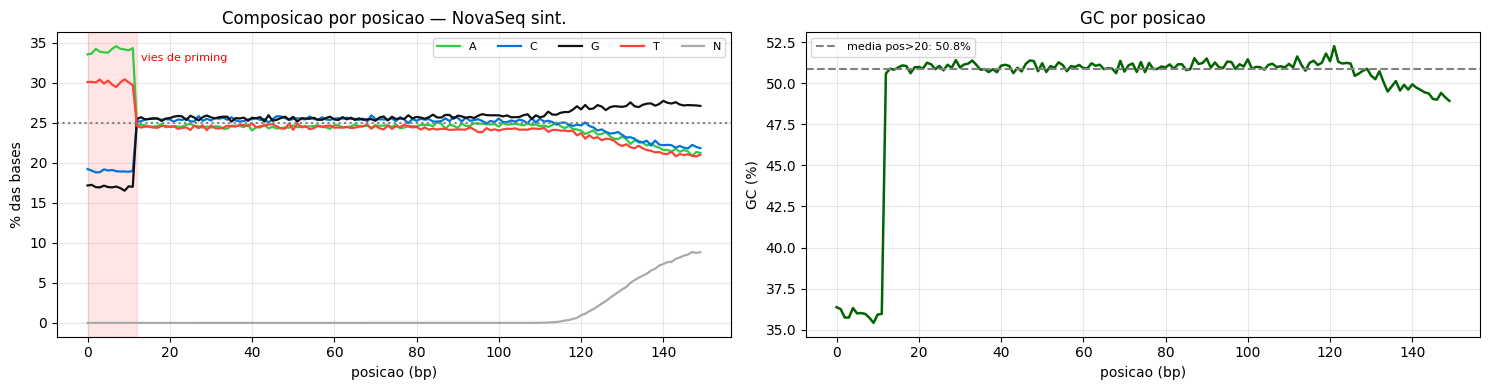

NovaSeq sint.: bases N = 1.096% | desvio maximo de 25% -> 12 primeiros bp: 9.0 p.p. | resto do read: 1.2 p.p.


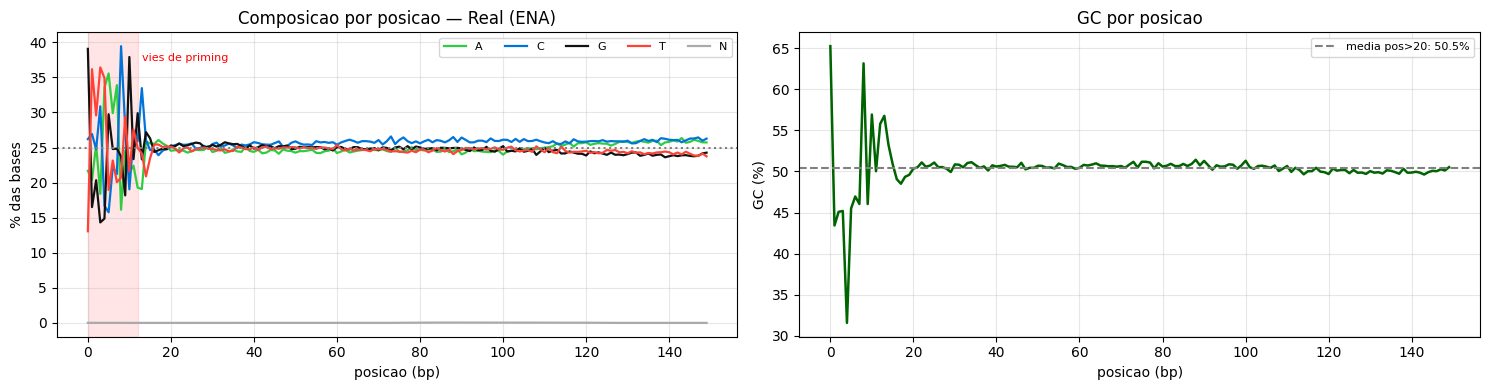

Real (ENA): bases N = 0.012% | desvio maximo de 25% -> 12 primeiros bp: 1.0 p.p. | resto do read: 0.8 p.p.


In [20]:
BASES = {"A": 65, "C": 67, "G": 71, "T": 84, "N": 78}
CORES = {"A": "#2ecc40", "C": "#0074d9", "G": "#111111", "T": "#ff4136", "N": "#aaaaaa"}

def composicao_por_posicao(d, rot):
    S, Q = d["S"], d["Q"]
    cob = np.sum(~np.isnan(Q), axis=0).astype(float)
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    for b, cod in BASES.items():
        frac = 100 * (S == cod).sum(axis=0) / np.maximum(cob, 1)
        axs[0].plot(frac, color=CORES[b], label=b, lw=1.6)
    axs[0].axvspan(0, 12, color="red", alpha=.10)
    axs[0].text(13, axs[0].get_ylim()[1]*0.9, "vies de priming", fontsize=8, color="red")
    axs[0].axhline(25, ls=":", color="gray")
    axs[0].set_xlabel("posicao (bp)"); axs[0].set_ylabel("% das bases")
    axs[0].set_title(f"Composicao por posicao — {rot}"); axs[0].legend(ncol=5, fontsize=8)

    gc = 100 * ((S == 71) | (S == 67)).sum(axis=0) / np.maximum(cob, 1)
    axs[1].plot(gc, color="darkgreen", lw=1.8)
    axs[1].axhline(gc[20:].mean(), ls="--", color="gray",
                   label=f"media pos>20: {gc[20:].mean():.1f}%")
    axs[1].set_xlabel("posicao (bp)"); axs[1].set_ylabel("GC (%)")
    axs[1].set_title("GC por posicao"); axs[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    frac_n = 100 * (S == 78).sum() / cob.sum()
    ini = max(abs(100*(S[:, :12] == BASES[b]).mean() - 25) for b in "ACGT")
    fim = max(abs(100*(S[:, 20:] == BASES[b]).mean() - 25) for b in "ACGT")
    print(f"{rot}: bases N = {frac_n:.3f}% | desvio maximo de 25% -> "
          f"12 primeiros bp: {ini:.1f} p.p. | resto do read: {fim:.1f} p.p.")

for rot, d in DADOS.items():
    composicao_por_posicao(d, rot)

### 2.6 Distribuição de GC entre reads

Com uma população de reads, o GC vira uma distribuição. Um genoma único produz uma curva
aproximadamente normal; **dois picos** denunciam contaminação ou mistura de organismos.

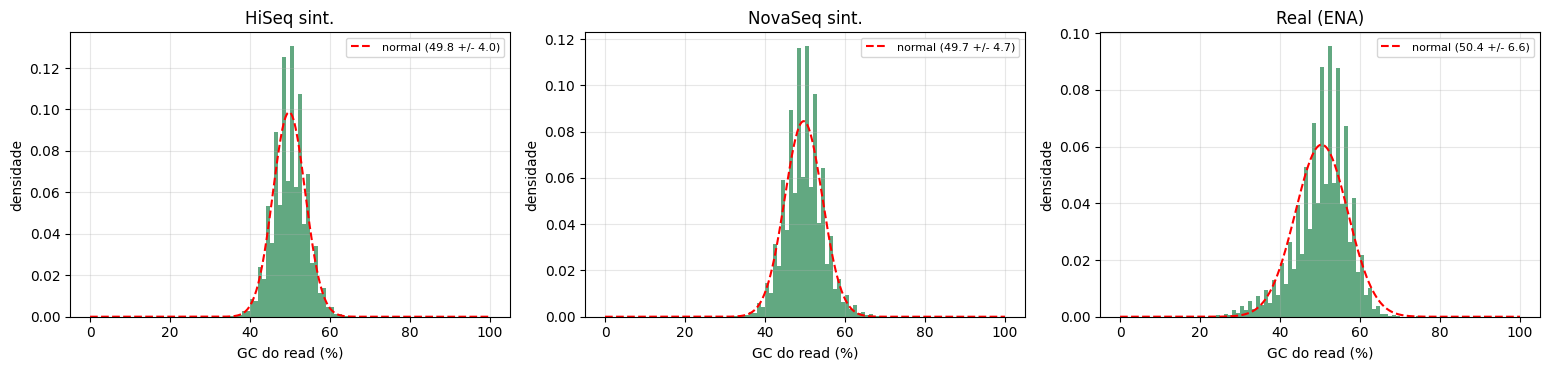

In [21]:
def distribuicao_gc(d, rot, ax):
    S, comp = d["S"], d["comp"]
    gc_read = 100 * ((S == 71) | (S == 67)).sum(axis=1) / np.maximum(comp, 1)
    ax.hist(gc_read, bins=np.arange(0, 101, 1), color="seagreen",
            edgecolor="none", alpha=.75, density=True)
    mu, sd = gc_read.mean(), gc_read.std()
    x = np.linspace(0, 100, 400)
    ax.plot(x, np.exp(-(x-mu)**2/(2*sd**2))/(sd*np.sqrt(2*np.pi)),
            "r--", lw=1.5, label=f"normal ({mu:.1f} +/- {sd:.1f})")
    ax.set_xlabel("GC do read (%)"); ax.set_ylabel("densidade")
    ax.set_title(rot); ax.legend(fontsize=8)
    return mu, sd

fig, axs = plt.subplots(1, len(DADOS), figsize=(5.2*len(DADOS), 3.8), squeeze=False)
for ax, (rot, d) in zip(axs[0], DADOS.items()):
    mu, sd = distribuicao_gc(d, rot, ax)
plt.tight_layout(); plt.show()

### 2.7 Contaminação por adaptador

Quando o fragmento de DNA é **mais curto que o read**, o sequenciador atravessa o inserto
e começa a ler o adaptador. Isso não é ruído: é sequência real, de alta qualidade, que
simplesmente não pertence ao genoma. Se não for removida, ela alinha em lugar nenhum —
ou pior, alinha em lugar errado.

Sonda: AGATCGGAAGAG (12 primeiros bp do TruSeq)

HiSeq sint.    :  5,299 reads com adaptador (10.60%) | inicio mediano na pos 105 (min 75, max 138)
NovaSeq sint.  :  4,264 reads com adaptador ( 8.53%) | inicio mediano na pos 100 (min 75, max 138)
Real (ENA)     :      0 reads com adaptador ( 0.00%)


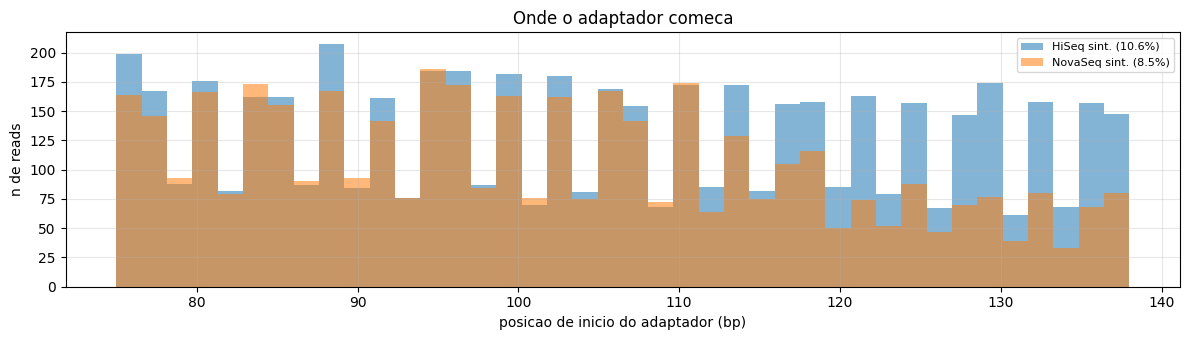

In [22]:
def detectar_adaptador(d, rot, adaptador=ADAPTADOR, k=12):
    sonda = adaptador[:k]
    posicoes = [s.find(sonda) for s in d["seqs"]]
    achou = np.array([p for p in posicoes if p >= 0])
    frac = 100 * len(achou) / len(posicoes)
    print(f"{rot:<15}: {len(achou):>6,} reads com adaptador ({frac:5.2f}%)", end="")
    if len(achou):
        print(f" | inicio mediano na pos {int(np.median(achou))} "
              f"(min {achou.min()}, max {achou.max()})")
    else:
        print()
    return achou, frac

print(f"Sonda: {ADAPTADOR[:12]} (12 primeiros bp do TruSeq)\n")
res_adap = {rot: detectar_adaptador(d, rot) for rot, d in DADOS.items()}

fig, ax = plt.subplots(figsize=(12, 3.5))
for rot, (achou, frac) in res_adap.items():
    if len(achou):
        ax.hist(achou, bins=40, alpha=.55, label=f"{rot} ({frac:.1f}%)")
ax.set_xlabel("posicao de inicio do adaptador (bp)"); ax.set_ylabel("n de reads")
ax.set_title("Onde o adaptador comeca"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.8 Duplicação e sequências superrepresentadas

Duplicatas de PCR são o **mesmo** fragmento amplificado várias vezes. Elas inflam
artificialmente a cobertura e podem transformar um erro de PCR em uma "variante" com
suporte de 30 reads. Usamos os 50 primeiros bp como impressão digital.

In [23]:
def analisar_duplicacao(d, rot, k=50, top=8):
    chaves = Counter(s[:k] for s in d["seqs"])
    n = len(d["seqs"])
    unicos = len(chaves)
    dup = 100 * (1 - unicos / n)
    print(f"\n=== {rot} ===")
    print(f"  reads: {n:,} | prefixos unicos: {unicos:,} | duplicacao: {dup:.2f}%")
    hist = Counter(chaves.values())
    print("  reads vistos 1x: {:.2f}% | 2x: {:.2f}% | >=3x: {:.2f}%".format(
        100*hist[1]/unicos,
        100*hist[2]/unicos,
        100*sum(v for c, v in hist.items() if c >= 3)/unicos))
    print(f"  top {top} sequencias superrepresentadas:")
    for s, c in chaves.most_common(top):
        if c < 2:
            break
        marca = " <-- ADAPTADOR" if ADAPTADOR[:12] in s else ""
        print(f"    {c:>5}x ({100*c/n:5.2f}%)  {s[:45]}...{marca}")
    return dup

dups = {rot: analisar_duplicacao(d, rot) for rot, d in DADOS.items()}


=== HiSeq sint. ===
  reads: 50,000 | prefixos unicos: 48,594 | duplicacao: 2.81%
  reads vistos 1x: 97.11% | 2x: 2.89% | >=3x: 0.00%
  top 8 sequencias superrepresentadas:
        2x ( 0.00%)  ATGCGATACGAAGATTCATCAATACCCCAAATAGAAGACAGGGCG...
        2x ( 0.00%)  TGGAATTTGTACCTGATTGTTGGGGGACCCTAACCTCGCTTGAGA...
        2x ( 0.00%)  ATATACTATGGATCGAGGTTCCCGTCCCCGGCTAGGTAACCATCG...
        2x ( 0.00%)  TTTGTTAAAAGAAAACGGCAACCGCCTCCGCACGTTGCGCCGACT...
        2x ( 0.00%)  GTGGTCAGATAACTACTGACCGAGGACTCACCGGAAGAGTTGTAA...
        2x ( 0.00%)  GCTAATATTCTTTAGAATGACCACTTCTCCGTAACCTCTATGGCA...
        2x ( 0.00%)  AGACATACCCAGGCGAACCCAAAGCGTAGATTGGAGTGATTGGCC...
        2x ( 0.00%)  TCACCCCATCAACTAATATGGTTTCAATGCCGCGACATAATGCGG...

=== NovaSeq sint. ===
  reads: 50,000 | prefixos unicos: 48,594 | duplicacao: 2.81%
  reads vistos 1x: 97.11% | 2x: 2.89% | >=3x: 0.00%
  top 8 sequencias superrepresentadas:
        2x ( 0.00%)  TTCACAGGTGTAGTGGGTGGCCATGCCCGGACTCTCCGCCCCAAG...
        2x ( 0.00%) 

### 2.9 Trimming em massa

Aplicamos a **mesma** função de Mott da Parte 1 — o algoritmo não muda com a tecnologia,
só a escala. Aqui vetorizamos a janela deslizante para rodar em 50 000 reads.

In [25]:
def trim_lote(Q, seqs, janela=4, qmin=20, min_comp=36, adaptador=ADAPTADOR, k=12):
    """Corta adaptador, depois aplica janela deslizante a partir do 3'."""
    manter, novos_comp = [], []
    sonda = adaptador[:k]
    for i, s in enumerate(seqs):
        q = Q[i][~np.isnan(Q[i])]
        fim = len(q)
        p = s.find(sonda)
        if p >= 0:
            fim = min(fim, p)
        while fim >= janela and q[fim-janela:fim].mean() < qmin:
            fim -= 1
        novos_comp.append(fim)
        manter.append(fim >= min_comp)
    return np.array(novos_comp), np.array(manter)

print(f"{'conjunto':<15} {'reads':>8} {'retidos':>8} {'bp antes':>11} {'bp depois':>11} "
      f"{'% mantido':>10} {'Q antes':>8} {'Q depois':>9} {'erros antes':>12} {'erros depois':>13}")
print("-" * 118)
RESUMO = {}
for rot, d in DADOS.items():
    Q, seqs = d["Q"], d["seqs"]
    novos, manter = trim_lote(Q, seqs)
    bases_antes = int(np.nansum(~np.isnan(Q)))
    bases_depois = int(novos[manter].sum())
    q_antes = np.nanmean(Q)
    q_depois = np.nanmean([Q[i][:novos[i]].mean() for i in np.flatnonzero(manter)[:5000]])
    err_antes = float(np.nansum(10.0 ** (-Q / 10.0)))
    err_depois = float(sum(np.sum(10.0 ** (-Q[i][:novos[i]] / 10.0))
                           for i in np.flatnonzero(manter)))
    RESUMO[rot] = dict(n=len(seqs), retidos=int(manter.sum()),
                       bases_antes=bases_antes, bases_depois=bases_depois,
                       q_antes=q_antes, q_depois=q_depois,
                       err_antes=err_antes, err_depois=err_depois,
                       novos=novos, manter=manter)
    print(f"{rot:<15} {len(seqs):>8,} {manter.sum():>8,} {bases_antes:>11,} {bases_depois:>11,} "
          f"{100*bases_depois/bases_antes:>9.1f}% {q_antes:>8.1f} {q_depois:>9.1f} "
          f"{err_antes:>12,.0f} {err_depois:>13,.0f}")

conjunto           reads  retidos    bp antes   bp depois  % mantido  Q antes  Q depois  erros antes  erros depois
----------------------------------------------------------------------------------------------------------------------
HiSeq sint.       50,000   50,000   7,500,000   5,356,648      71.4%     28.0      34.1      170,283         5,779
NovaSeq sint.     50,000   50,000   7,500,000   5,555,908      74.1%     28.3      34.0      175,937        10,616
Real (ENA)        50,000   49,876   7,500,000   7,050,872      94.0%     32.5      34.2      307,531        26,686


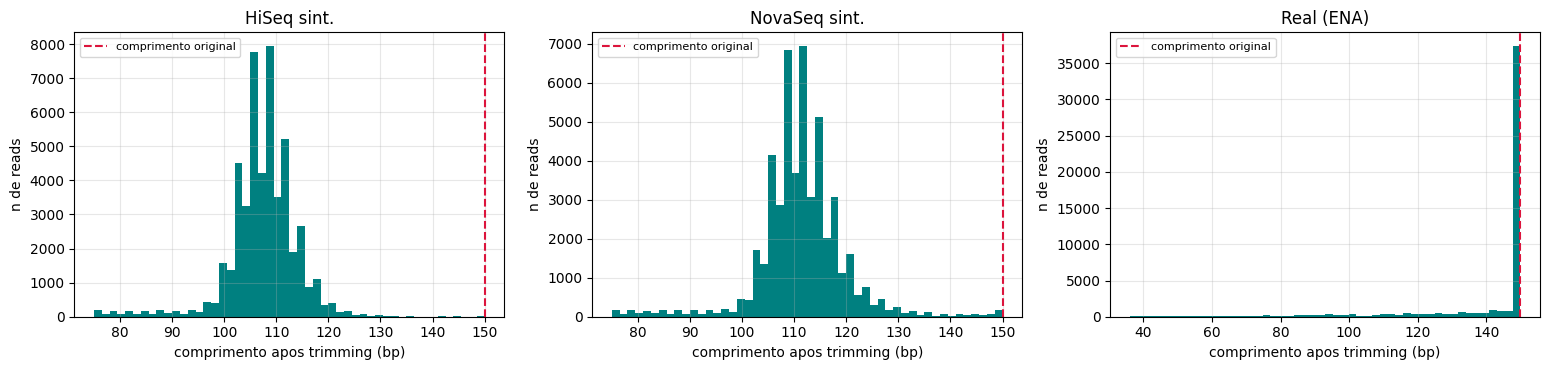

Agora os reads tem comprimentos DIFERENTES — releia a questao Q8.


In [26]:
fig, axs = plt.subplots(1, len(DADOS), figsize=(5.2*len(DADOS), 3.8), squeeze=False)
for ax, (rot, r) in zip(axs[0], RESUMO.items()):
    ax.hist(r["novos"][r["manter"]], bins=50, color="teal", edgecolor="none")
    ax.axvline(DADOS[rot]["S"].shape[1], color="crimson", ls="--", label="comprimento original")
    ax.set_xlabel("comprimento apos trimming (bp)"); ax.set_ylabel("n de reads")
    ax.set_title(rot); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Agora os reads tem comprimentos DIFERENTES — releia a questao Q7.")

---
# PARTE 3 — Contraste entre as três fontes

A mesma métrica, três tecnologias. Repare que **nenhuma coluna vence em tudo**: Sanger
ganha em comprimento e Q de pico, Illumina ganha em número de bases por ordens de
grandeza.

In [27]:
def metricas(seqs, Qmat_ou_lista, rot):
    if isinstance(Qmat_ou_lista, np.ndarray) and Qmat_ou_lista.ndim == 2:
        Q = Qmat_ou_lista
        todos = Q[~np.isnan(Q)]
        comp = np.sum(~np.isnan(Q), axis=1)
    else:
        todos = np.concatenate(Qmat_ou_lista)
        comp = np.array([len(q) for q in Qmat_ou_lista])
    total = todos.size
    return {
        "fonte": rot,
        "n reads": len(seqs),
        "comp. medio": f"{comp.mean():.0f}",
        "total bases": f"{total:,}",
        "Q medio": f"{todos.mean():.1f}",
        "Q max": f"{todos.max():.0f}",
        "Q distintos": len(np.unique(todos.astype(int))),
        "% Q>=20": f"{100*(todos>=20).mean():.1f}",
        "% Q>=30": f"{100*(todos>=30).mean():.1f}",
        "% N": f"{100*sum(s.count('N') for s in seqs)/total:.2f}",
        "erros esp.": f"{np.sum(10.0**(-todos/10.0)):,.0f}",
        "err/Mb": f"{1e6*np.sum(10.0**(-todos/10.0))/total:,.0f}",
    }

tabela = [metricas(seqsF, qualsF, "Sanger (F)")]
if FQ_R:
    tabela.append(metricas(seqsR, qualsR, "Sanger (R)"))
for rot, d in DADOS.items():
    tabela.append(metricas(d["seqs"], d["Q"], rot))

cols = list(tabela[0])
larg = {c: max(len(str(c)), max(len(str(l[c])) for l in tabela)) + 2 for c in cols}
print("".join(f"{c:>{larg[c]}}" for c in cols))
print("-" * sum(larg.values()))
for l in tabela:
    print("".join(f"{str(l[c]):>{larg[c]}}" for c in cols))

          fonte  n reads  comp. medio  total bases  Q medio  Q max  Q distintos  % Q>=20  % Q>=30   % N  erros esp.   err/Mb
----------------------------------------------------------------------------------------------------------------------------
     Sanger (F)        1          942          942     16.9     55           53     36.2     18.9  2.02         143  151,915
     Sanger (R)        1          620          620     19.2     50           46     48.9     22.6  1.94          68  109,291
    HiSeq sint.    50000          150    7,500,000     28.0     41           41     71.2     59.1  0.09     170,283   22,704
  NovaSeq sint.    50000          150    7,500,000     28.3     37            4     74.1     59.1  1.10     175,937   23,458
     Real (ENA)    50000          150    7,500,000     32.5     41           38     91.4     83.0  0.01     307,531   41,004


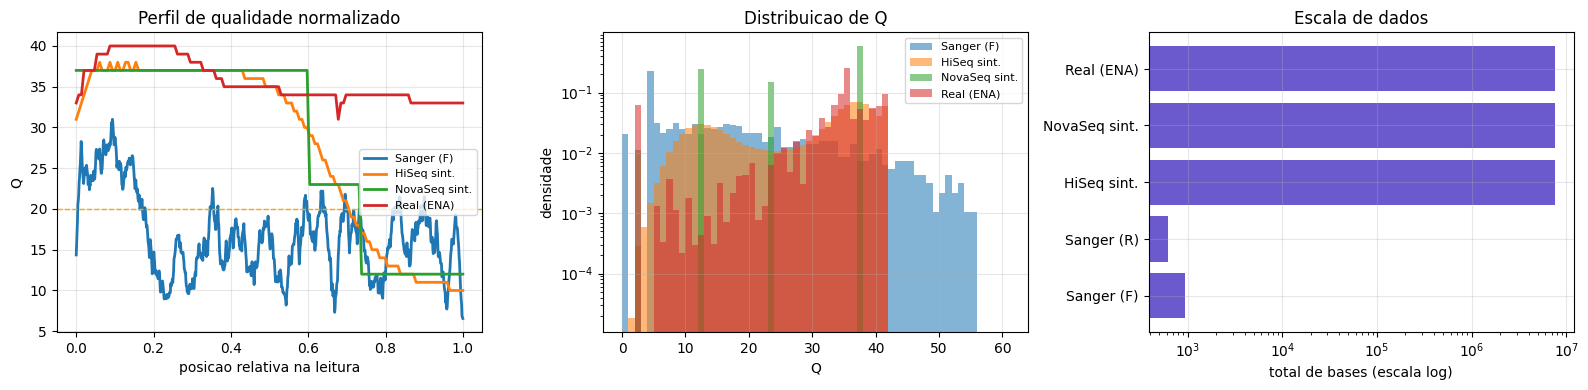

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# (1) perfis de Q normalizados pela posicao relativa
axs[0].plot(np.linspace(0, 1, len(qF)), np.convolve(qF, np.ones(25)/25, "same"),
            label="Sanger (F)", lw=2)
for rot, d in DADOS.items():
    axs[0].plot(np.linspace(0, 1, d["Q"].shape[1]), np.nanmedian(d["Q"], axis=0),
                label=rot, lw=2)
axs[0].axhline(20, ls="--", color="orange", lw=1)
axs[0].set_xlabel("posicao relativa na leitura"); axs[0].set_ylabel("Q")
axs[0].set_title("Perfil de qualidade normalizado"); axs[0].legend(fontsize=8)

# (2) distribuicao de Q
axs[1].hist(qF, bins=np.arange(0, 62), alpha=.55, density=True, label="Sanger (F)")
for rot, d in DADOS.items():
    t = d["Q"][~np.isnan(d["Q"])]
    axs[1].hist(t, bins=np.arange(0, 62), alpha=.55, density=True, label=rot)
axs[1].set_xlabel("Q"); axs[1].set_ylabel("densidade"); axs[1].set_yscale("log")
axs[1].set_title("Distribuicao de Q"); axs[1].legend(fontsize=8)

# (3) escala: bases totais
rots = [l["fonte"] for l in tabela]
bases = [int(l["total bases"].replace(",", "")) for l in tabela]
axs[2].barh(rots, bases, color="slateblue")
axs[2].set_xscale("log"); axs[2].set_xlabel("total de bases (escala log)")
axs[2].set_title("Escala de dados")
plt.tight_layout(); plt.show()

In [ ]:
if META_REAL:
    print("Metadados do conjunto real utilizado:")
    for k, v in META_REAL.items():
        print(f"  {k:<20}: {v}")
else:
    print("Nenhum conjunto real foi baixado nesta sessao.")

> **Q9.** Confira na tabela da Seção 3 os valores de % Q>=30 e erro/Mb para Sanger e para o HiSeq sintético.

(a) As duas métricas concordam sobre qual tecnologia é "melhor" nesta leitura específica, ou uma delas conta uma história diferente da outra? Justifique com os números que você obteve.

(b) Independente do que aconteceu nesta leitura, explique por que, em princípio, % Q>=30 e erro/Mb podem discordar — pense no que cada métrica ignora que a outra captura (dica: uma é uma fração de bases acima de um corte; a outra é uma soma ponderada, que trata Q=29 quase como Q=30).

(c) Diga qual métrica você usaria para decidir entre Sanger e Illumina em cada cenário, e por quê:

- confirmar uma mutação pontual conhecida em 20 pacientes;
- montar de novo o genoma de uma bactéria não caracterizada;
- validar a sequência de um plasmídeo construído em laboratório.

---
### Créditos e leituras

- **Ewing & Green (1998)**, *Base-calling of automated sequencer traces using Phred* —
  a origem do escore $Q$.
- **Mott (1997)** — o algoritmo de trimming implementado na Seção 1.6.
- **FastQC / MultiQC** — as versões de produção do painel da Seção 2.4.
- **fastp** — implementa `--trim_poly_g` para o artefato da Seção 2.9.
- **ENA Browser** <https://www.ebi.ac.uk/ena> — fonte dos dados reais.